# Test HKJC Football DataProvider

## 0. Import Packages

In [1]:
# Import Libraries
## Standard Libraries
import datetime
import json
import logging
import os
import sys

## Third-Party Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Local Libraries
sys.path.append("D:\\workspace\\hkjc_football")
from hkjc_core.data.data_provider import HKJC_Football_DataProvider
from hkjc_core.data.data_parser import HKJC_Football_DataParser


In [2]:
hkjc_fb_dp = HKJC_Football_DataProvider(
    instance_id=42,
    log_level=logging.DEBUG,
    base_url="https://info.cld.hkjc.com/graphql/base/",
    max_retries=3,
    retry_backoff_factor=0.3,
)

In [3]:
parser = HKJC_Football_DataParser()

## 1. Test Query for Team IDs

In [4]:
team_id_dict = hkjc_fb_dp.get_team_ids()
team_info_df = pd.DataFrame(team_id_dict)
print(len(team_info_df))
team_info_df.head()


5415


,id,code,name_ch,name_en
0,50000001,TMN,1860慕尼黑,1860 Munich
1,50430573,WBA,3B亞馬遜女足,3B da Amazonia Women
2,50000002,OCT,十月九日,9 de Octubre
3,50000003,AAS,澳職明星隊,A-League All Stars
4,50000004,AAG,真特,AA Gent


In [5]:
team_info_df.loc[team_info_df["name_en"] == "Real Madrid"]

,id,code,name_ch,name_en
4121,50002589,RMD,皇家馬德里,Real Madrid


In [6]:
# team_info_df.to_csv("D:\\workspace\\hkjc_football\\sample_data\\team_data\\team_infos_table.csv", index=False)

## 2. Test Query for Match Results

In [7]:
match_results = hkjc_fb_dp.get_match_results(
    start_date=datetime.date(2026, 1, 1),
    end_date=datetime.date(2026, 6, 28),
    team_id="50002589",
)
len(match_results)

31

In [8]:
match_results

[{'id': '50060631',
  'status': 'MATCHENDED',
  'frontEndId': 'FB2757',
  'matchDayOfWeek': '',
  'matchNumber': '',
  'matchDate': '2026-01-29+08:00',
  'kickOffTime': '2026-01-29T04:00:00.000+08:00',
  'sequence': '1.1769630400.11.UE Champions                                                                                                                    .1.08.Benfica                                                                                                                         .000',
  'homeTeam': {'id': '50000449', 'name_en': 'Benfica', 'name_ch': '賓菲加'},
  'awayTeam': {'id': '50002589', 'name_en': 'Real Madrid', 'name_ch': '皇家馬德里'},
  'tournament': {'code': 'UCL',
   'name_en': 'UE Champions',
   'name_ch': '歐洲聯賽冠軍盃'},
  'results': [{'homeResult': 0,
    'awayResult': 1,
    'ttlCornerResult': -1,
    'resultConfirmType': 5,
    'payoutConfirmed': True,
    'stageId': 2,
    'resultType': 1,
    'sequence': 45},
   {'homeResult': 1,
    'awayResult': 1,
    'ttlCornerRes

In [9]:
match_results_parsed = pd.DataFrame(
    [parser.parse_match_result(match_result) for match_result in match_results]
)
match_results_parsed


No corners result found for HT (stageId=3).
match_result_list: [{'homeResult': 1, 'awayResult': 0, 'ttlCornerResult': -1, 'resultConfirmType': 5, 'payoutConfirmed': True, 'stageId': 2, 'resultType': 1, 'sequence': 46}, {'homeResult': 1, 'awayResult': 1, 'ttlCornerResult': -1, 'resultConfirmType': 5, 'payoutConfirmed': True, 'stageId': 3, 'resultType': 1, 'sequence': 47}, {'homeResult': 2, 'awayResult': 1, 'ttlCornerResult': -1, 'resultConfirmType': 5, 'payoutConfirmed': True, 'stageId': 4, 'resultType': 1, 'sequence': 48}, {'homeResult': 2, 'awayResult': 2, 'ttlCornerResult': -1, 'resultConfirmType': 5, 'payoutConfirmed': True, 'stageId': 4, 'resultType': 1, 'sequence': 49}, {'homeResult': 3, 'awayResult': 2, 'ttlCornerResult': -1, 'resultConfirmType': 5, 'payoutConfirmed': True, 'stageId': 5, 'resultType': 1, 'sequence': 50}, {'homeResult': 1, 'awayResult': 5, 'ttlCornerResult': -1, 'resultConfirmType': 5, 'payoutConfirmed': False, 'stageId': 3, 'resultType': 2, 'sequence': 51}, {'hom

,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,...,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners
0,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,...,3,4,2,6,5.0,1.0,6.0,6.0,5.0,11.0
1,50060535,FB2624,2026-01-25 04:00:00+08:00,"[FCS, SGA, NTS, SGA, FGS, SGA, HHA, SGA, LGS, ...",[],"[FCS, SGA, NTS, FGS, HHA, LGS, FCH, CHD, HDC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50003323,...,0,0,2,2,4.0,2.0,6.0,6.0,6.0,12.0
2,50058963,FB2425,2026-01-21 04:00:00+08:00,"[SGA, SGA, HAD, LGS, SGA, NTS, SGA, NTS, FTS, ...",[],"[SGA, HAD, LGS, NTS, FTS, HFT, TTG, MSP, CRS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50002589,...,2,6,1,7,3.0,3.0,6.0,10.0,6.0,16.0
3,50060131,FB2317,2026-01-17 21:00:00+08:00,"[SGA, SGA, LGS, CHL, HFT, CHD, SGA, SGA, FHA, ...",[],"[SGA, LGS, CHL, HFT, CHD, FHA, HAD, FCH, NTS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,...,0,2,0,2,2.0,0.0,2.0,8.0,0.0,8.0
4,50060276,FB2157,2026-01-15 04:00:00+08:00,"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",[],"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",SFC,Spanish Cup,西班牙盃,50000121,...,2,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN
5,50060271,FB2018,2026-01-12 03:00:00+08:00,"[FHC, NTS, HIL, NTS, SGA, SGA, SGA, HHA, SGA, ...",[],"[FHC, NTS, HIL, SGA, HHA, TTG, FHL, CHD, FTS, ...",SSC,Spanish Super Cup,西班牙超級盃,50000369,...,4,3,2,5,4.0,3.0,7.0,5.0,6.0,11.0
6,50059731,FB1882,2026-01-09 03:00:00+08:00,"[SGA, HHA, SGA, LGS, NTS, FCH, MSP, FGS, SGA, ...",[],"[SGA, HHA, LGS, NTS, FCH, MSP, FGS, AGS, HDC, ...",SSC,Spanish Super Cup,西班牙超級盃,50000267,...,1,1,2,3,4.0,0.0,4.0,9.0,1.0,10.0
7,50059173,FB1716,2026-01-04 23:15:00+08:00,"[NTS, LGS, SGA, FHL, SGA, CHD, SGA, SGA, FCS, ...",[],"[NTS, LGS, SGA, FHL, CHD, FCS, HAD, FTS, TTG, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,...,1,5,1,6,3.0,4.0,7.0,5.0,8.0,13.0
8,50062755,FB4636,2026-03-03 04:00:00+08:00,"[SGA, LGS, FCH, SGA, CHD, SGA, SGA, SGA, SGA, ...",[],"[SGA, LGS, FCH, CHD, FHA, HHA, CHL, OOE, FGS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,...,1,0,1,1,4.0,1.0,5.0,10.0,2.0,12.0
9,50062427,FB4408,2026-02-26 04:00:00+08:00,"[HIL, SGA, SGA, SGA, SGA, NTS, FCS, AGS, NTS, ...","[SGA, MSP]","[HIL, SGA, NTS, FCS, AGS, CRS, MSP, FHC, HFT, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50002589,...,2,2,1,3,2.0,3.0,5.0,4.0,7.0,11.0


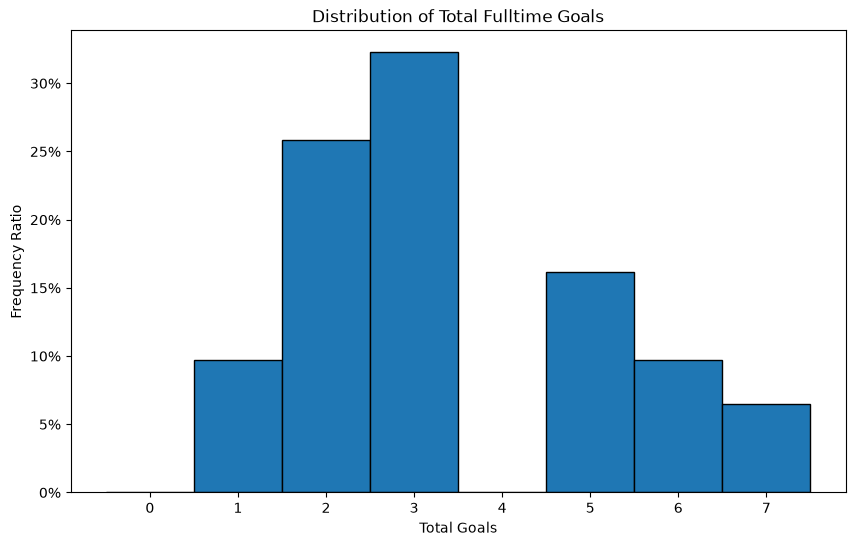

In [10]:
total_goals = match_results_parsed["FT_total_goals"]
plt.figure(figsize=(10, 6))
plt.hist(total_goals, bins=range(0, total_goals.max() + 2), edgecolor='black', align='left', weights=np.ones(len(total_goals)) / len(total_goals))
plt.xlabel('Total Goals')
plt.ylabel('Frequency Ratio')
plt.title('Distribution of Total Fulltime Goals')
plt.xticks(range(0, total_goals.max() + 1))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.show()


In [11]:
match_results_parsed.to_csv("../../../../sample_data/match_data/match_results_sample_Real_Madrid_20260101-20260628.csv", index=False)

## 3. Test Query for Match Odds

In [12]:
match_odds = hkjc_fb_dp.get_match_odds_in_batch(
    match_id_list=match_results_parsed["match_id"].unique().tolist(),
)
len(match_odds)

31

In [13]:
match_odds[0].keys()

dict_keys(['id', 'updateAt', 'statusUpdatedAt', 'foPools'])

In [14]:
match_odds_container = []

for match_odds_unit in match_odds:

    match_odds_parsed = pd.DataFrame(
        parser.parse_match_odds(match_odds_unit)
    )
    match_odds_container.append(match_odds_parsed)

match_odds_df = pd.concat(match_odds_container, ignore_index=True)
match_odds_df


,match_id,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
0,50060631,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,in-play,1,PAYOUTSTARTED,3.0/3.5,1,H,WIN,1.88,H,High,大
1,50060631,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,in-play,1,PAYOUTSTARTED,3.0/3.5,2,L,LOSE,1.82,L,Low,細
2,50060631,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,in-play,2,PAYOUTSTARTED,3.5,1,H,WIN,2.13,H,High,大
3,50060631,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,in-play,2,PAYOUTSTARTED,3.5,2,L,LOSE,1.63,L,Low,細
4,50060631,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,in-play,3,PAYOUTSTARTED,4.5,1,H,WIN,3.40,H,High,大
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14465,50068238,2026-05-11 06:31:06.069000+08:00,FHA,1645921002,PAYOUTSTARTED,0,True,in-play,0,PAYOUTSTARTED,0.0,2,A,LOSE,150.00,A,Away,客隊勝
14466,50068238,2026-05-11 06:31:06.069000+08:00,FHA,1645921002,PAYOUTSTARTED,0,True,in-play,0,PAYOUTSTARTED,0.0,3,D,LOSE,15.50,D,Draw,和
14467,50068238,2026-05-11 06:31:06.069000+08:00,FHA,1645921002,PAYOUTSTARTED,0,True,pre-play,0,AVAILABLE,0.0,1,H,AVAILABLE,1.84,H,Home,主隊勝
14468,50068238,2026-05-11 06:31:06.069000+08:00,FHA,1645921002,PAYOUTSTARTED,0,True,pre-play,0,AVAILABLE,0.0,2,A,AVAILABLE,4.45,A,Away,客隊勝


In [15]:
match_odds_df.to_csv("../../../../sample_data/match_data/match_odds_sample_Real_Madrid_20260101-20260628.csv", index=False)

In [16]:
# analysis
match_result_and_odds_df = match_results_parsed.merge(match_odds_df, on="match_id", how="left")
match_result_and_odds_df_selected = match_result_and_odds_df.loc[
    (match_result_and_odds_df["odds_type"] == "HIL") &
    (match_result_and_odds_df["line_type"] == "pre-play")
]
match_result_and_odds_df_selected



,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,...,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
6,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,...,2,AVAILABLE,3.5,1,H,AVAILABLE,2.13,H,High,大
7,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,...,2,AVAILABLE,3.5,2,L,AVAILABLE,1.63,L,Low,細
8,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,...,1,AVAILABLE,3.0/3.5,1,H,AVAILABLE,1.88,H,High,大
9,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,...,1,AVAILABLE,3.0/3.5,2,L,AVAILABLE,1.82,L,Low,細
10,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,...,3,AVAILABLE,4.5,1,H,AVAILABLE,3.40,H,High,大
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14375,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,...,4,AVAILABLE,4.0/4.5,2,L,AVAILABLE,1.46,L,Low,細
14376,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,...,3,AVAILABLE,4.5,1,H,AVAILABLE,2.70,H,High,大
14377,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,...,3,AVAILABLE,4.5,2,L,AVAILABLE,1.39,L,Low,細
14378,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,...,5,AVAILABLE,5.5,1,H,AVAILABLE,4.40,H,High,大


In [18]:
match_id_list = match_result_and_odds_df_selected["match_id"].unique().tolist()
pd.set_option('display.max_columns', None)
for match_id in match_id_list:
    display(match_result_and_odds_df_selected.loc[match_result_and_odds_df_selected["match_id"] == match_id])

,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
6,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,Benfica,賓菲加,50002589,Real Madrid,皇家馬德里,2,1,3,4,2,6,5.0,1.0,6.0,6.0,5.0,11.0,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,pre-play,2,AVAILABLE,3.5,1,H,AVAILABLE,2.13,H,High,大
7,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,Benfica,賓菲加,50002589,Real Madrid,皇家馬德里,2,1,3,4,2,6,5.0,1.0,6.0,6.0,5.0,11.0,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,pre-play,2,AVAILABLE,3.5,2,L,AVAILABLE,1.63,L,Low,細
8,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,Benfica,賓菲加,50002589,Real Madrid,皇家馬德里,2,1,3,4,2,6,5.0,1.0,6.0,6.0,5.0,11.0,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,pre-play,1,AVAILABLE,3.0/3.5,1,H,AVAILABLE,1.88,H,High,大
9,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,Benfica,賓菲加,50002589,Real Madrid,皇家馬德里,2,1,3,4,2,6,5.0,1.0,6.0,6.0,5.0,11.0,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,pre-play,1,AVAILABLE,3.0/3.5,2,L,AVAILABLE,1.82,L,Low,細
10,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,Benfica,賓菲加,50002589,Real Madrid,皇家馬德里,2,1,3,4,2,6,5.0,1.0,6.0,6.0,5.0,11.0,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,pre-play,3,AVAILABLE,4.5,1,H,AVAILABLE,3.40,H,High,大
11,50060631,FB2757,2026-01-29 04:00:00+08:00,"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",[LGS],"[HIL, OOE, HFT, TTG, LGS, CHL, FCH, FHA, FGS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50000449,Benfica,賓菲加,50002589,Real Madrid,皇家馬德里,2,1,3,4,2,6,5.0,1.0,6.0,6.0,5.0,11.0,2026-01-30 06:31:04.813000+08:00,HIL,1420671003,PAYOUTSTARTED,0,False,pre-play,3,AVAILABLE,4.5,2,L,AVAILABLE,1.26,L,Low,細


,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
536,50060535,FB2624,2026-01-25 04:00:00+08:00,"[FCS, SGA, NTS, SGA, FGS, SGA, HHA, SGA, LGS, ...",[],"[FCS, SGA, NTS, FGS, HHA, LGS, FCH, CHD, HDC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50003323,Villarreal,維拉利爾,50002589,Real Madrid,皇家馬德里,0,0,0,0,2,2,4.0,2.0,6.0,6.0,6.0,12.0,2026-01-25 06:31:05.697000+08:00,HIL,1417669003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5,1,H,AVAILABLE,2.08,H,High,大
537,50060535,FB2624,2026-01-25 04:00:00+08:00,"[FCS, SGA, NTS, SGA, FGS, SGA, HHA, SGA, LGS, ...",[],"[FCS, SGA, NTS, FGS, HHA, LGS, FCH, CHD, HDC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50003323,Villarreal,維拉利爾,50002589,Real Madrid,皇家馬德里,0,0,0,0,2,2,4.0,2.0,6.0,6.0,6.0,12.0,2026-01-25 06:31:05.697000+08:00,HIL,1417669003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5,2,L,AVAILABLE,1.66,L,Low,細
538,50060535,FB2624,2026-01-25 04:00:00+08:00,"[FCS, SGA, NTS, SGA, FGS, SGA, HHA, SGA, LGS, ...",[],"[FCS, SGA, NTS, FGS, HHA, LGS, FCH, CHD, HDC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50003323,Villarreal,維拉利爾,50002589,Real Madrid,皇家馬德里,0,0,0,0,2,2,4.0,2.0,6.0,6.0,6.0,12.0,2026-01-25 06:31:05.697000+08:00,HIL,1417669003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.0/3.5,1,H,AVAILABLE,1.85,H,High,大
539,50060535,FB2624,2026-01-25 04:00:00+08:00,"[FCS, SGA, NTS, SGA, FGS, SGA, HHA, SGA, LGS, ...",[],"[FCS, SGA, NTS, FGS, HHA, LGS, FCH, CHD, HDC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50003323,Villarreal,維拉利爾,50002589,Real Madrid,皇家馬德里,0,0,0,0,2,2,4.0,2.0,6.0,6.0,6.0,12.0,2026-01-25 06:31:05.697000+08:00,HIL,1417669003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.0/3.5,2,L,AVAILABLE,1.85,L,Low,細
540,50060535,FB2624,2026-01-25 04:00:00+08:00,"[FCS, SGA, NTS, SGA, FGS, SGA, HHA, SGA, LGS, ...",[],"[FCS, SGA, NTS, FGS, HHA, LGS, FCH, CHD, HDC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50003323,Villarreal,維拉利爾,50002589,Real Madrid,皇家馬德里,0,0,0,0,2,2,4.0,2.0,6.0,6.0,6.0,12.0,2026-01-25 06:31:05.697000+08:00,HIL,1417669003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,1,H,AVAILABLE,3.40,H,High,大
541,50060535,FB2624,2026-01-25 04:00:00+08:00,"[FCS, SGA, NTS, SGA, FGS, SGA, HHA, SGA, LGS, ...",[],"[FCS, SGA, NTS, FGS, HHA, LGS, FCH, CHD, HDC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50003323,Villarreal,維拉利爾,50002589,Real Madrid,皇家馬德里,0,0,0,0,2,2,4.0,2.0,6.0,6.0,6.0,12.0,2026-01-25 06:31:05.697000+08:00,HIL,1417669003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,2,L,AVAILABLE,1.26,L,Low,細


,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
996,50058963,FB2425,2026-01-21 04:00:00+08:00,"[SGA, SGA, HAD, LGS, SGA, NTS, SGA, NTS, FTS, ...",[],"[SGA, HAD, LGS, NTS, FTS, HFT, TTG, MSP, CRS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50002589,Real Madrid,皇家馬德里,50002140,Monaco,摩納哥,2,0,2,6,1,7,3.0,3.0,6.0,10.0,6.0,16.0,2026-01-21 06:31:04.928000+08:00,HIL,1386586003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.5,1,H,AVAILABLE,1.74,H,High,大
997,50058963,FB2425,2026-01-21 04:00:00+08:00,"[SGA, SGA, HAD, LGS, SGA, NTS, SGA, NTS, FTS, ...",[],"[SGA, HAD, LGS, NTS, FTS, HFT, TTG, MSP, CRS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50002589,Real Madrid,皇家馬德里,50002140,Monaco,摩納哥,2,0,2,6,1,7,3.0,3.0,6.0,10.0,6.0,16.0,2026-01-21 06:31:04.928000+08:00,HIL,1386586003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.5,2,L,AVAILABLE,1.97,L,Low,細
998,50058963,FB2425,2026-01-21 04:00:00+08:00,"[SGA, SGA, HAD, LGS, SGA, NTS, SGA, NTS, FTS, ...",[],"[SGA, HAD, LGS, NTS, FTS, HFT, TTG, MSP, CRS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50002589,Real Madrid,皇家馬德里,50002140,Monaco,摩納哥,2,0,2,6,1,7,3.0,3.0,6.0,10.0,6.0,16.0,2026-01-21 06:31:04.928000+08:00,HIL,1386586003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5/4.0,1,H,AVAILABLE,1.91,H,High,大
999,50058963,FB2425,2026-01-21 04:00:00+08:00,"[SGA, SGA, HAD, LGS, SGA, NTS, SGA, NTS, FTS, ...",[],"[SGA, HAD, LGS, NTS, FTS, HFT, TTG, MSP, CRS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50002589,Real Madrid,皇家馬德里,50002140,Monaco,摩納哥,2,0,2,6,1,7,3.0,3.0,6.0,10.0,6.0,16.0,2026-01-21 06:31:04.928000+08:00,HIL,1386586003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5/4.0,2,L,AVAILABLE,1.79,L,Low,細
1000,50058963,FB2425,2026-01-21 04:00:00+08:00,"[SGA, SGA, HAD, LGS, SGA, NTS, SGA, NTS, FTS, ...",[],"[SGA, HAD, LGS, NTS, FTS, HFT, TTG, MSP, CRS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50002589,Real Madrid,皇家馬德里,50002140,Monaco,摩納哥,2,0,2,6,1,7,3.0,3.0,6.0,10.0,6.0,16.0,2026-01-21 06:31:04.928000+08:00,HIL,1386586003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,1,H,AVAILABLE,2.60,H,High,大
1001,50058963,FB2425,2026-01-21 04:00:00+08:00,"[SGA, SGA, HAD, LGS, SGA, NTS, SGA, NTS, FTS, ...",[],"[SGA, HAD, LGS, NTS, FTS, HFT, TTG, MSP, CRS, ...",UCL,UE Champions,歐洲聯賽冠軍盃,50002589,Real Madrid,皇家馬德里,50002140,Monaco,摩納哥,2,0,2,6,1,7,3.0,3.0,6.0,10.0,6.0,16.0,2026-01-21 06:31:04.928000+08:00,HIL,1386586003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,2,L,AVAILABLE,1.43,L,Low,細


,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
1470,50060131,FB2317,2026-01-17 21:00:00+08:00,"[SGA, SGA, LGS, CHL, HFT, CHD, SGA, SGA, FHA, ...",[],"[SGA, LGS, CHL, HFT, CHD, FHA, HAD, FCH, NTS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50001900,Levante,利雲特,0,0,0,2,0,2,2.0,0.0,2.0,8.0,0.0,8.0,2026-01-18 06:31:05.751000+08:00,HIL,1404217003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.5,1,H,AVAILABLE,1.58,H,High,大
1471,50060131,FB2317,2026-01-17 21:00:00+08:00,"[SGA, SGA, LGS, CHL, HFT, CHD, SGA, SGA, FHA, ...",[],"[SGA, LGS, CHL, HFT, CHD, FHA, HAD, FCH, NTS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50001900,Levante,利雲特,0,0,0,2,0,2,2.0,0.0,2.0,8.0,0.0,8.0,2026-01-18 06:31:05.751000+08:00,HIL,1404217003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.5,2,L,AVAILABLE,2.22,L,Low,細
1472,50060131,FB2317,2026-01-17 21:00:00+08:00,"[SGA, SGA, LGS, CHL, HFT, CHD, SGA, SGA, FHA, ...",[],"[SGA, LGS, CHL, HFT, CHD, FHA, HAD, FCH, NTS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50001900,Levante,利雲特,0,0,0,2,0,2,2.0,0.0,2.0,8.0,0.0,8.0,2026-01-18 06:31:05.751000+08:00,HIL,1404217003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5/4.0,1,H,AVAILABLE,1.71,H,High,大
1473,50060131,FB2317,2026-01-17 21:00:00+08:00,"[SGA, SGA, LGS, CHL, HFT, CHD, SGA, SGA, FHA, ...",[],"[SGA, LGS, CHL, HFT, CHD, FHA, HAD, FCH, NTS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50001900,Levante,利雲特,0,0,0,2,0,2,2.0,0.0,2.0,8.0,0.0,8.0,2026-01-18 06:31:05.751000+08:00,HIL,1404217003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5/4.0,2,L,AVAILABLE,2.01,L,Low,細
1474,50060131,FB2317,2026-01-17 21:00:00+08:00,"[SGA, SGA, LGS, CHL, HFT, CHD, SGA, SGA, FHA, ...",[],"[SGA, LGS, CHL, HFT, CHD, FHA, HAD, FCH, NTS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50001900,Levante,利雲特,0,0,0,2,0,2,2.0,0.0,2.0,8.0,0.0,8.0,2026-01-18 06:31:05.751000+08:00,HIL,1404217003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,1,H,AVAILABLE,2.30,H,High,大
1475,50060131,FB2317,2026-01-17 21:00:00+08:00,"[SGA, SGA, LGS, CHL, HFT, CHD, SGA, SGA, FHA, ...",[],"[SGA, LGS, CHL, HFT, CHD, FHA, HAD, FCH, NTS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50001900,Levante,利雲特,0,0,0,2,0,2,2.0,0.0,2.0,8.0,0.0,8.0,2026-01-18 06:31:05.751000+08:00,HIL,1404217003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,2,L,AVAILABLE,1.54,L,Low,細


,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
1660,50060276,FB2157,2026-01-15 04:00:00+08:00,"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",[],"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",SFC,Spanish Cup,西班牙盃,50000121,Albacete,阿爾巴塞特,50002589,Real Madrid,皇家馬德里,1,1,2,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-15 06:31:05.547000+08:00,HIL,1409295003,PAYOUTSTARTED,0,False,pre-play,1,AVAILABLE,3.5,1,H,AVAILABLE,1.92,H,High,大
1661,50060276,FB2157,2026-01-15 04:00:00+08:00,"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",[],"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",SFC,Spanish Cup,西班牙盃,50000121,Albacete,阿爾巴塞特,50002589,Real Madrid,皇家馬德里,1,1,2,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-15 06:31:05.547000+08:00,HIL,1409295003,PAYOUTSTARTED,0,False,pre-play,1,AVAILABLE,3.5,2,L,AVAILABLE,1.78,L,Low,細
1662,50060276,FB2157,2026-01-15 04:00:00+08:00,"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",[],"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",SFC,Spanish Cup,西班牙盃,50000121,Albacete,阿爾巴塞特,50002589,Real Madrid,皇家馬德里,1,1,2,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-15 06:31:05.547000+08:00,HIL,1409295003,PAYOUTSTARTED,0,False,pre-play,2,AVAILABLE,3.5/4.0,1,H,AVAILABLE,2.17,H,High,大
1663,50060276,FB2157,2026-01-15 04:00:00+08:00,"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",[],"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",SFC,Spanish Cup,西班牙盃,50000121,Albacete,阿爾巴塞特,50002589,Real Madrid,皇家馬德里,1,1,2,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-15 06:31:05.547000+08:00,HIL,1409295003,PAYOUTSTARTED,0,False,pre-play,2,AVAILABLE,3.5/4.0,2,L,AVAILABLE,1.61,L,Low,細
1664,50060276,FB2157,2026-01-15 04:00:00+08:00,"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",[],"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",SFC,Spanish Cup,西班牙盃,50000121,Albacete,阿爾巴塞特,50002589,Real Madrid,皇家馬德里,1,1,2,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-15 06:31:05.547000+08:00,HIL,1409295003,PAYOUTSTARTED,0,False,pre-play,3,AVAILABLE,4.5,1,H,AVAILABLE,3.05,H,High,大
1665,50060276,FB2157,2026-01-15 04:00:00+08:00,"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",[],"[TTG, LGS, FHA, HHA, FCS, HIL, FTS, CRS, AGS, ...",SFC,Spanish Cup,西班牙盃,50000121,Albacete,阿爾巴塞特,50002589,Real Madrid,皇家馬德里,1,1,2,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-15 06:31:05.547000+08:00,HIL,1409295003,PAYOUTSTARTED,0,False,pre-play,3,AVAILABLE,4.5,2,L,AVAILABLE,1.32,L,Low,細


...

,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
12055,50065105,FB6754,2026-04-04 22:15:00+08:00,"[NTS, HFT, NTS, SGA, HAD, AGS, FTS, FHH, SGA, ...",[],"[NTS, HFT, SGA, HAD, AGS, FTS, FHH, NGS, FCS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002016,Mallorca,馬略卡,50002589,Real Madrid,皇家馬德里,1,0,1,2,1,3,2.0,3.0,5.0,6.0,4.0,10.0,2026-04-05 06:31:05.119000+08:00,HIL,1548072003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,3.5,1,H,AVAILABLE,2.25,H,High,大
12056,50065105,FB6754,2026-04-04 22:15:00+08:00,"[NTS, HFT, NTS, SGA, HAD, AGS, FTS, FHH, SGA, ...",[],"[NTS, HFT, SGA, HAD, AGS, FTS, FHH, NGS, FCS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002016,Mallorca,馬略卡,50002589,Real Madrid,皇家馬德里,1,0,1,2,1,3,2.0,3.0,5.0,6.0,4.0,10.0,2026-04-05 06:31:05.119000+08:00,HIL,1548072003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,3.5,2,L,AVAILABLE,1.57,L,Low,細
12057,50065105,FB6754,2026-04-04 22:15:00+08:00,"[NTS, HFT, NTS, SGA, HAD, AGS, FTS, FHH, SGA, ...",[],"[NTS, HFT, SGA, HAD, AGS, FTS, FHH, NGS, FCS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002016,Mallorca,馬略卡,50002589,Real Madrid,皇家馬德里,1,0,1,2,1,3,2.0,3.0,5.0,6.0,4.0,10.0,2026-04-05 06:31:05.119000+08:00,HIL,1548072003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,2.5,1,H,AVAILABLE,1.46,H,High,大
12058,50065105,FB6754,2026-04-04 22:15:00+08:00,"[NTS, HFT, NTS, SGA, HAD, AGS, FTS, FHH, SGA, ...",[],"[NTS, HFT, SGA, HAD, AGS, FTS, FHH, NGS, FCS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002016,Mallorca,馬略卡,50002589,Real Madrid,皇家馬德里,1,0,1,2,1,3,2.0,3.0,5.0,6.0,4.0,10.0,2026-04-05 06:31:05.119000+08:00,HIL,1548072003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,2.5,2,L,AVAILABLE,2.50,L,Low,細
12059,50065105,FB6754,2026-04-04 22:15:00+08:00,"[NTS, HFT, NTS, SGA, HAD, AGS, FTS, FHH, SGA, ...",[],"[NTS, HFT, SGA, HAD, AGS, FTS, FHH, NGS, FCS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002016,Mallorca,馬略卡,50002589,Real Madrid,皇家馬德里,1,0,1,2,1,3,2.0,3.0,5.0,6.0,4.0,10.0,2026-04-05 06:31:05.119000+08:00,HIL,1548072003,PAYOUTSTARTED,0,True,pre-play,4,AVAILABLE,3.0/3.5,1,H,AVAILABLE,2.01,H,High,大
12060,50065105,FB6754,2026-04-04 22:15:00+08:00,"[NTS, HFT, NTS, SGA, HAD, AGS, FTS, FHH, SGA, ...",[],"[NTS, HFT, SGA, HAD, AGS, FTS, FHH, NGS, FCS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002016,Mallorca,馬略卡,50002589,Real Madrid,皇家馬德里,1,0,1,2,1,3,2.0,3.0,5.0,6.0,4.0,10.0,2026-04-05 06:31:05.119000+08:00,HIL,1548072003,PAYOUTSTARTED,0,True,pre-play,4,AVAILABLE,3.0/3.5,2,L,AVAILABLE,1.71,L,Low,細


,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
12457,50069357,FB0130,2026-05-24 03:00:00+08:00,"[NGS, NGS, SGA, NTS, CRS, SGA, SGA, FCS, CFA, ...",[],"[NGS, SGA, NTS, CRS, FCS, CFA, HIL, CHA, FCH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50000465,Bilbao,畢爾包,2,1,3,4,2,6,2.0,1.0,3.0,2.0,1.0,3.0,2026-05-24 06:31:04.722000+08:00,HIL,1690268003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5,1,H,AVAILABLE,2.13,H,High,大
12458,50069357,FB0130,2026-05-24 03:00:00+08:00,"[NGS, NGS, SGA, NTS, CRS, SGA, SGA, FCS, CFA, ...",[],"[NGS, SGA, NTS, CRS, FCS, CFA, HIL, CHA, FCH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50000465,Bilbao,畢爾包,2,1,3,4,2,6,2.0,1.0,3.0,2.0,1.0,3.0,2026-05-24 06:31:04.722000+08:00,HIL,1690268003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5,2,L,AVAILABLE,1.63,L,Low,細
12459,50069357,FB0130,2026-05-24 03:00:00+08:00,"[NGS, NGS, SGA, NTS, CRS, SGA, SGA, FCS, CFA, ...",[],"[NGS, SGA, NTS, CRS, FCS, CFA, HIL, CHA, FCH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50000465,Bilbao,畢爾包,2,1,3,4,2,6,2.0,1.0,3.0,2.0,1.0,3.0,2026-05-24 06:31:04.722000+08:00,HIL,1690268003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.0/3.5,1,H,AVAILABLE,1.90,H,High,大
12460,50069357,FB0130,2026-05-24 03:00:00+08:00,"[NGS, NGS, SGA, NTS, CRS, SGA, SGA, FCS, CFA, ...",[],"[NGS, SGA, NTS, CRS, FCS, CFA, HIL, CHA, FCH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50000465,Bilbao,畢爾包,2,1,3,4,2,6,2.0,1.0,3.0,2.0,1.0,3.0,2026-05-24 06:31:04.722000+08:00,HIL,1690268003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.0/3.5,2,L,AVAILABLE,1.80,L,Low,細
12461,50069357,FB0130,2026-05-24 03:00:00+08:00,"[NGS, NGS, SGA, NTS, CRS, SGA, SGA, FCS, CFA, ...",[],"[NGS, SGA, NTS, CRS, FCS, CFA, HIL, CHA, FCH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50000465,Bilbao,畢爾包,2,1,3,4,2,6,2.0,1.0,3.0,2.0,1.0,3.0,2026-05-24 06:31:04.722000+08:00,HIL,1690268003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,1,H,AVAILABLE,3.55,H,High,大
12462,50069357,FB0130,2026-05-24 03:00:00+08:00,"[NGS, NGS, SGA, NTS, CRS, SGA, SGA, FCS, CFA, ...",[],"[NGS, SGA, NTS, CRS, FCS, CFA, HIL, CHA, FCH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50000465,Bilbao,畢爾包,2,1,3,4,2,6,2.0,1.0,3.0,2.0,1.0,3.0,2026-05-24 06:31:04.722000+08:00,HIL,1690268003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,2,L,AVAILABLE,1.24,L,Low,細


,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
13140,50068892,FB9816,2026-05-18 01:00:00+08:00,"[SGA, SGA, OOE, FTS, SGA, SGA, FLA, SGA, NTS, ...",[],"[SGA, OOE, FTS, FLA, NTS, CFA, HHA, CFH, FHC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002804,Sevilla,西維爾,50002589,Real Madrid,皇家馬德里,0,1,1,0,1,1,2.0,3.0,5.0,4.0,4.0,8.0,2026-05-18 06:31:05.770000+08:00,HIL,1670564003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,2.5,1,H,AVAILABLE,1.55,H,High,大
13141,50068892,FB9816,2026-05-18 01:00:00+08:00,"[SGA, SGA, OOE, FTS, SGA, SGA, FLA, SGA, NTS, ...",[],"[SGA, OOE, FTS, FLA, NTS, CFA, HHA, CFH, FHC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002804,Sevilla,西維爾,50002589,Real Madrid,皇家馬德里,0,1,1,0,1,1,2.0,3.0,5.0,4.0,4.0,8.0,2026-05-18 06:31:05.770000+08:00,HIL,1670564003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,2.5,2,L,AVAILABLE,2.29,L,Low,細
13142,50068892,FB9816,2026-05-18 01:00:00+08:00,"[SGA, SGA, OOE, FTS, SGA, SGA, FLA, SGA, NTS, ...",[],"[SGA, OOE, FTS, FLA, NTS, CFA, HHA, CFH, FHC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002804,Sevilla,西維爾,50002589,Real Madrid,皇家馬德里,0,1,1,0,1,1,2.0,3.0,5.0,4.0,4.0,8.0,2026-05-18 06:31:05.770000+08:00,HIL,1670564003,PAYOUTSTARTED,0,True,pre-play,4,AVAILABLE,3.0/3.5,1,H,AVAILABLE,2.19,H,High,大
13143,50068892,FB9816,2026-05-18 01:00:00+08:00,"[SGA, SGA, OOE, FTS, SGA, SGA, FLA, SGA, NTS, ...",[],"[SGA, OOE, FTS, FLA, NTS, CFA, HHA, CFH, FHC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002804,Sevilla,西維爾,50002589,Real Madrid,皇家馬德里,0,1,1,0,1,1,2.0,3.0,5.0,4.0,4.0,8.0,2026-05-18 06:31:05.770000+08:00,HIL,1670564003,PAYOUTSTARTED,0,True,pre-play,4,AVAILABLE,3.0/3.5,2,L,AVAILABLE,1.60,L,Low,細
13144,50068892,FB9816,2026-05-18 01:00:00+08:00,"[SGA, SGA, OOE, FTS, SGA, SGA, FLA, SGA, NTS, ...",[],"[SGA, OOE, FTS, FLA, NTS, CFA, HHA, CFH, FHC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002804,Sevilla,西維爾,50002589,Real Madrid,皇家馬德里,0,1,1,0,1,1,2.0,3.0,5.0,4.0,4.0,8.0,2026-05-18 06:31:05.770000+08:00,HIL,1670564003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,3.5,1,H,AVAILABLE,2.40,H,High,大
13145,50068892,FB9816,2026-05-18 01:00:00+08:00,"[SGA, SGA, OOE, FTS, SGA, SGA, FLA, SGA, NTS, ...",[],"[SGA, OOE, FTS, FLA, NTS, CFA, HHA, CFH, FHC, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002804,Sevilla,西維爾,50002589,Real Madrid,皇家馬德里,0,1,1,0,1,1,2.0,3.0,5.0,4.0,4.0,8.0,2026-05-18 06:31:05.770000+08:00,HIL,1670564003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,3.5,2,L,AVAILABLE,1.50,L,Low,細


,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
13774,50068544,FB9548,2026-05-15 03:30:00+08:00,"[HHA, AGS, SGA, FCS, CHA, FHC, SGA, SGA, FLH, ...",[],"[HHA, AGS, SGA, FCS, CHA, FHC, FLH, OOE, NGS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50002367,Oviedo,奧維多,1,0,1,2,0,2,2.0,3.0,5.0,4.0,5.0,9.0,2026-05-15 06:31:05.412000+08:00,HIL,1657061003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.5,1,H,AVAILABLE,1.97,H,High,大
13775,50068544,FB9548,2026-05-15 03:30:00+08:00,"[HHA, AGS, SGA, FCS, CHA, FHC, SGA, SGA, FLH, ...",[],"[HHA, AGS, SGA, FCS, CHA, FHC, FLH, OOE, NGS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50002367,Oviedo,奧維多,1,0,1,2,0,2,2.0,3.0,5.0,4.0,5.0,9.0,2026-05-15 06:31:05.412000+08:00,HIL,1657061003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.5,2,L,AVAILABLE,1.74,L,Low,細
13776,50068544,FB9548,2026-05-15 03:30:00+08:00,"[HHA, AGS, SGA, FCS, CHA, FHC, SGA, SGA, FLH, ...",[],"[HHA, AGS, SGA, FCS, CHA, FHC, FLH, OOE, NGS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50002367,Oviedo,奧維多,1,0,1,2,0,2,2.0,3.0,5.0,4.0,5.0,9.0,2026-05-15 06:31:05.412000+08:00,HIL,1657061003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5/4.0,1,H,AVAILABLE,2.25,H,High,大
13777,50068544,FB9548,2026-05-15 03:30:00+08:00,"[HHA, AGS, SGA, FCS, CHA, FHC, SGA, SGA, FLH, ...",[],"[HHA, AGS, SGA, FCS, CHA, FHC, FLH, OOE, NGS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50002367,Oviedo,奧維多,1,0,1,2,0,2,2.0,3.0,5.0,4.0,5.0,9.0,2026-05-15 06:31:05.412000+08:00,HIL,1657061003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5/4.0,2,L,AVAILABLE,1.57,L,Low,細
13778,50068544,FB9548,2026-05-15 03:30:00+08:00,"[HHA, AGS, SGA, FCS, CHA, FHC, SGA, SGA, FLH, ...",[],"[HHA, AGS, SGA, FCS, CHA, FHC, FLH, OOE, NGS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50002367,Oviedo,奧維多,1,0,1,2,0,2,2.0,3.0,5.0,4.0,5.0,9.0,2026-05-15 06:31:05.412000+08:00,HIL,1657061003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,1,H,AVAILABLE,3.15,H,High,大
13779,50068544,FB9548,2026-05-15 03:30:00+08:00,"[HHA, AGS, SGA, FCS, CHA, FHC, SGA, SGA, FLH, ...",[],"[HHA, AGS, SGA, FCS, CHA, FHC, FLH, OOE, NGS, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50002589,Real Madrid,皇家馬德里,50002367,Oviedo,奧維多,1,0,1,2,0,2,2.0,3.0,5.0,4.0,5.0,9.0,2026-05-15 06:31:05.412000+08:00,HIL,1657061003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,2,L,AVAILABLE,1.30,L,Low,細


,match_id,front_end_id,kick_off_time,defined_pools,refund_pools,payout_refund_pools,tournament_code,tournament_name_en,tournament_name_ch,home_team_id,home_team_name_en,home_team_name_ch,away_team_id,away_team_name_en,away_team_name_ch,HT_home_goals,HT_away_goals,HT_total_goals,FT_home_goals,FT_away_goals,FT_total_goals,HT_home_corners,HT_away_corners,HT_total_corners,FT_home_corners,FT_away_corners,FT_total_corners,updated_at,odds_type,pool_id,pool_status,inst_no,inplay,line_type,line_id,line_status,condition,comb_id,str,status,current_odds,selection_str,selection_name_en,selection_name_ch
14370,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Real Madrid,皇家馬德里,2,0,2,2,0,2,1.0,4.0,5.0,4.0,8.0,12.0,2026-05-11 06:31:06.069000+08:00,HIL,1645922003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.5,1,H,AVAILABLE,1.75,H,High,大
14371,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Real Madrid,皇家馬德里,2,0,2,2,0,2,1.0,4.0,5.0,4.0,8.0,12.0,2026-05-11 06:31:06.069000+08:00,HIL,1645922003,PAYOUTSTARTED,0,True,pre-play,1,AVAILABLE,3.5,2,L,AVAILABLE,1.95,L,Low,細
14372,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Real Madrid,皇家馬德里,2,0,2,2,0,2,1.0,4.0,5.0,4.0,8.0,12.0,2026-05-11 06:31:06.069000+08:00,HIL,1645922003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5/4.0,1,H,AVAILABLE,1.93,H,High,大
14373,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Real Madrid,皇家馬德里,2,0,2,2,0,2,1.0,4.0,5.0,4.0,8.0,12.0,2026-05-11 06:31:06.069000+08:00,HIL,1645922003,PAYOUTSTARTED,0,True,pre-play,2,AVAILABLE,3.5/4.0,2,L,AVAILABLE,1.77,L,Low,細
14374,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Real Madrid,皇家馬德里,2,0,2,2,0,2,1.0,4.0,5.0,4.0,8.0,12.0,2026-05-11 06:31:06.069000+08:00,HIL,1645922003,PAYOUTSTARTED,0,True,pre-play,4,AVAILABLE,4.0/4.5,1,H,AVAILABLE,2.50,H,High,大
14375,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Real Madrid,皇家馬德里,2,0,2,2,0,2,1.0,4.0,5.0,4.0,8.0,12.0,2026-05-11 06:31:06.069000+08:00,HIL,1645922003,PAYOUTSTARTED,0,True,pre-play,4,AVAILABLE,4.0/4.5,2,L,AVAILABLE,1.46,L,Low,細
14376,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Real Madrid,皇家馬德里,2,0,2,2,0,2,1.0,4.0,5.0,4.0,8.0,12.0,2026-05-11 06:31:06.069000+08:00,HIL,1645922003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,1,H,AVAILABLE,2.70,H,High,大
14377,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Real Madrid,皇家馬德里,2,0,2,2,0,2,1.0,4.0,5.0,4.0,8.0,12.0,2026-05-11 06:31:06.069000+08:00,HIL,1645922003,PAYOUTSTARTED,0,True,pre-play,3,AVAILABLE,4.5,2,L,AVAILABLE,1.39,L,Low,細
14378,50068238,FB9213,2026-05-11 03:00:00+08:00,"[NGS, SGA, SGA, FTS, NTS, HFT, CFA, HAD, SGA, ...",[],"[NGS, SGA, FTS, NTS, HFT, CFA, HAD, HHA, CFH, ...",SFL,Spanish Division 1,西班牙甲組聯賽,50000369,Barcelona,巴塞隆拿,50002589,Rea

## 4. Test Query for Live Match Data

In [ ]:
live_match_data = hkjc_fb_dp.get_live_matches(
    match_id_list=["50069886"]
)
live_match_data

In [ ]:
with open("../../../../sample_data/match_data/live_match_data_sample_20260612.json", "w") as f:
    f.write(json.dumps(live_match_data, indent=4))

## 5. Test Query for All Live Matches

In [ ]:
all_live_matches = hkjc_fb_dp.get_all_live_matches()
print(len(all_live_matches))


In [ ]:
all_live_matches[0]

In [ ]:
all_live_matches[0].keys()

In [ ]:
for match in all_live_matches:
    print(f"{match['homeTeam']['name_ch']} v.s. {match['awayTeam']['name_ch']}")

In [ ]:
with open("../../../../sample_data/match_data/all_live_matches_sample_20260612.json", "w") as f:
    f.write(json.dumps(all_live_matches, indent=4))